# Document Parsing

Document parsing is the process of turning a source document into usable content for the downstream RAG pipeline.

The key question is:

> **How do we extract useful information without losing structure and context that matter later?**

In this notebook, we will work with:

- Plain text (`.txt`)
- Markdown (`.md`)
- HTML (`.html`)
- DOCX (`.docx`)
- PDF (`.pdf`)

The documents intentionally contain different structures so we can see why parsing is an engineering problem.


## Learning Objectives

By the end of this notebook, you should be able to:

- Explain what document parsing means in a RAG pipeline.
- Identify an appropriate parser for common document formats.
- Parse TXT, Markdown, HTML, DOCX, and PDF files.
- Inspect source documents before parsing them.
- Compare raw source content with parser output.
- Preserve useful structure and metadata.
- Recognize information that can be lost during parsing.
- Understand how parsing errors propagate into later RAG stages.

**Module boundary:** This notebook introduces general document parsing. Detailed PDF layout analysis and OCR are covered in later notebooks.


## 1. Where Parsing Fits

Our document-ingestion flow is:

```text
Raw Document
     ↓
Validate & Register
     ↓
Parse
     ↓
OCR if Required
     ↓
Clean & Normalize
     ↓
Structure + Metadata
     ↓
Validate
     ↓
Ready for Chunking
```

This notebook focuses on **Parse**.

We are not doing chunking, embeddings, or vector indexing yet.


## 2. The Documents

The `data/` directory contains the source documents used throughout this notebook:

| File | Format | What it demonstrates |
|---|---|---|
| `customer_refund_policy.txt` | TXT | Plain text extraction |
| `internal_rag_engineering_guide.md` | Markdown | Headings, lists, code blocks |
| `support_refunds.html` | HTML | DOM structure, metadata, sections |
| `q3_customer_support_operating_brief.docx` | DOCX | Headings, paragraphs, tables, properties |
| `employee_travel_policy.pdf` | PDF | Pages, text, and tabular content |

These are synthetic but realistic training documents created specifically for this course.


## 3. Install the Parsing Libraries

Run this cell once in the current Jupyter environment.

We use format-specific libraries because each source format represents information differently.


In [1]:
!pip install -q beautifulsoup4 python-docx pymupdf


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 4. Load the Data Directory

The notebook expects this structure:

```text
02-document-parsing.ipynb
data/
├── customer_refund_policy.txt
├── internal_rag_engineering_guide.md
├── support_refunds.html
├── q3_customer_support_operating_brief.docx
└── employee_travel_policy.pdf
```


In [2]:
from pathlib import Path

DATA_DIR = Path("./data")

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "The data/ directory was not found. "
        "Place the supplied documents inside a folder named data/"
    )

expected_files = [
    "customer_refund_policy.txt",
    "internal_rag_engineering_guide.md",
    "support_refunds.html",
    "q3_customer_support_operating_brief.docx",
    "employee_travel_policy.pdf",
]

missing_files = [
    filename for filename in expected_files
    if not (DATA_DIR / filename).exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following documents are missing:\n"
        + "\n".join(f"- {filename}" for filename in missing_files)
    )
print("All source documents are available.")

All source documents are available.


In [3]:
for path in sorted(DATA_DIR.iterdir()):
    if path.is_file():
        print(f"{path.name:45} {path.stat().st_size:>8} bytes")

README.md                                         1053 bytes
customer_refund_policy.txt                        1162 bytes
employee_travel_policy.pdf                       44745 bytes
internal_rag_engineering_guide.md                 1175 bytes
q3_customer_support_operating_brief.docx       1005174 bytes
q3_customer_support_operating_brief.pdf         241357 bytes
scanned_travel_claim.pdf                      11609643 bytes
support_refunds.html                              1434 bytes
travel_claim.png                                120970 bytes


Before parsing, we verify the inputs.

This matters in a real ingestion system because a missing, corrupt, or unexpected file should not silently enter the pipeline.


## 5. Parse Plain Text

Our first source is:

`data/customer_refund_policy.txt`

Plain text is the simplest case because there is little layout information to reconstruct.


In [4]:
txt_path = DATA_DIR / "customer_refund_policy.txt"

txt_content = txt_path.read_text(encoding="utf-8")

print(txt_content)

CUSTOMER REFUND AND CANCELLATION POLICY
Document ID: POL-REF-2026-001
Version: 2.1
Effective Date: 15 August 2026
Owner: Customer Operations

1. Purpose

This policy explains when customers may request a refund or cancel an eligible purchase.

2. Refund Eligibility

Customers may request a refund within 30 calendar days of the original purchase date.
The request must relate to an eligible product or service and must include the order
reference associated with the purchase.

3. Review Process

Refund requests are reviewed by the Customer Operations team. A request may be
approved, partially approved, or declined depending on the applicable product terms.

4. Processing Time

Approved refunds are normally processed within 7 business days. The time required
for the funds to appear in the customer's account may depend on the payment provider.

5. Exceptions

Digital products that have been fully consumed may not qualify for a refund.
Additional product-specific terms may apply.

6. Contact

The extracted text is already close to what a downstream RAG component needs.

However, the text should remain associated with its source.

For example:

```python
{
    "source": "customer_refund_policy.txt",
    "text": txt_content,
}
```

This relationship becomes important for provenance, citations, debugging, and document updates.


### Inspect the document structure

Even a plain-text document can contain useful logical structure.

In our policy, look for:

- Document ID
- Version
- Effective date
- Section headings
- Policy rules
- Exceptions
- Source information

The parser does not necessarily need to convert every heading into a special object at this stage, but downstream stages should not lose the information accidentally.


## 6. Parse Markdown

Next:

`data/internal_rag_engineering_guide.md`

Markdown mixes content with lightweight markup.

Let's first inspect the original source.


In [5]:
md_path = DATA_DIR / "internal_rag_engineering_guide.md"

md_content = md_path.read_text(encoding="utf-8")

print(md_content)

# Internal RAG Engineering Guide

**Document ID:** ENG-RAG-2026-014  
**Version:** 1.3  
**Owner:** AI Platform Engineering  
**Last Updated:** 20 August 2026

## Purpose

This guide describes the baseline architecture used for internal retrieval-augmented
generation experiments.

## Pipeline

The baseline pipeline contains the following stages:

1. Document ingestion
2. Chunking
3. Embedding generation
4. Vector indexing
5. Retrieval
6. Context construction
7. Generation
8. Evaluation

## Retrieval

The baseline retriever uses semantic similarity over document embeddings.

> Retrieval quality should be measured independently from answer quality.

## Metadata

Every indexed chunk should retain enough metadata to trace the result back to its
source document.

Recommended fields include:

```text
document_id
source
page
section
chunk_id
```

## Engineering Notes

Do not assume that a successful parser produced correct content. Ingestion output
should be inspected and validated before it 

Notice that the document contains headings, lists, a blockquote, a code block, and ordinary paragraphs.

For example:

```markdown
## Retrieval

The baseline retriever uses semantic similarity...
```

The `##` is syntax, but the heading also carries meaning.

If we flatten everything into plain text, we may lose the relationship between a section and its content.


### Extract Markdown structure

For this lesson, we will use a lightweight parser rather than treating Markdown as an opaque string.

Install the Markdown parser.


In [6]:
!pip install -q markdown


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import markdown

md_html = markdown.markdown(md_content)

print(md_html)

<h1>Internal RAG Engineering Guide</h1>
<p><strong>Document ID:</strong> ENG-RAG-2026-014<br />
<strong>Version:</strong> 1.3<br />
<strong>Owner:</strong> AI Platform Engineering<br />
<strong>Last Updated:</strong> 20 August 2026</p>
<h2>Purpose</h2>
<p>This guide describes the baseline architecture used for internal retrieval-augmented
generation experiments.</p>
<h2>Pipeline</h2>
<p>The baseline pipeline contains the following stages:</p>
<ol>
<li>Document ingestion</li>
<li>Chunking</li>
<li>Embedding generation</li>
<li>Vector indexing</li>
<li>Retrieval</li>
<li>Context construction</li>
<li>Generation</li>
<li>Evaluation</li>
</ol>
<h2>Retrieval</h2>
<p>The baseline retriever uses semantic similarity over document embeddings.</p>
<blockquote>
<p>Retrieval quality should be measured independently from answer quality.</p>
</blockquote>
<h2>Metadata</h2>
<p>Every indexed chunk should retain enough metadata to trace the result back to its
source document.</p>
<p>Recommended fields 

The Markdown parser converts the document into structured HTML.

This is useful because we can now distinguish elements such as:

```text
<h1> -> title
<h2> -> section
<p>  -> paragraph
<ol> -> ordered list
<pre> -> code block
<blockquote> -> quoted text
```

The important engineering point is that **parsing can preserve structure instead of immediately flattening everything into a string**.


## 7. Parse HTML

Now:

`data/support_refunds.html`

HTML contains several different kinds of information:

```text
Page metadata
Navigation
Article content
Section structure
HTML attributes
Footer / presentation elements
```

First inspect the raw source.


In [8]:
html_path = DATA_DIR / "support_refunds.html"

html_content = html_path.read_text(encoding="utf-8")

print(html_content)

<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <title>Support Knowledge Base — Refunds</title>
  <meta name="description" content="Customer support information about refunds and cancellations">
  <style>
    body { font-family: Arial; }
    .navigation { background: #eee; }
    .footer { color: #777; }
  </style>
</head>
<body>
  <nav class="navigation">
    <a href="/home">Home</a>
    <a href="/billing">Billing</a>
    <a href="/support">Support</a>
  </nav>

  <main>
    <article data-document-id="KB-REF-2026-07">
      <header>
        <p class="category">Billing</p>
        <h1>Refunds and Cancellations</h1>
        <p class="updated">Updated 18 August 2026</p>
      </header>

      <section data-section="eligibility">
        <h2>Refund eligibility</h2>
        <p>Eligible customers can request a refund within <strong>30 calendar days</strong>
        of the original purchase.</p>
      </section>

      <section data-section="processing">
        <h2>Process

Now parse the HTML document with BeautifulSoup.

In [9]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html_content, "html.parser")
html_text = soup.get_text(" ", strip=True)
print(html_text)

Support Knowledge Base — Refunds Home Billing Support Billing Refunds and Cancellations Updated 18 August 2026 Refund eligibility Eligible customers can request a refund within 30 calendar days of the original purchase. Processing time Approved refunds are normally processed within 7 business days . Contact support Include your order reference when contacting the support team. Copyright 2026 Example Support. All rights reserved.


The extracted text is cleaner, but notice what the simple extraction discarded.

The source contains useful attributes such as:

```text
data-document-id
data-section
category
updated date
```

A production parser may want to preserve these values.


In [10]:
article = soup.find("article")
article_metadata = {
    "document_id": article.get("data-document-id"),
    "category": article.find("p", class_="category").get_text(strip=True),
    "updated": article.find("p", class_="updated").get_text(strip=True),
}
article_metadata

{'document_id': 'KB-REF-2026-07',
 'category': 'Billing',
 'updated': 'Updated 18 August 2026'}

Now extract the individual sections.

In [11]:
sections = []

for section in article.find_all("section"):
    heading = section.find(["h2", "h3"])
    
    sections.append({
        "section_id": section.get("data-section"),
        "heading": heading.get_text(" ", strip=True) if heading else None,
        "text": section.get_text(" ", strip=True)
    })
sections

[{'section_id': 'eligibility',
  'heading': 'Refund eligibility',
  'text': 'Refund eligibility Eligible customers can request a refund within 30 calendar days of the original purchase.'},
 {'section_id': 'processing',
  'heading': 'Processing time',
  'text': 'Processing time Approved refunds are normally processed within 7 business days .'},
 {'section_id': 'contact',
  'heading': 'Contact support',
  'text': 'Contact support Include your order reference when contacting the support team.'}]

This representation preserves:

```text
document identity
section identity
section heading
section content
```

That is much more useful for downstream RAG work than an unstructured block of text.


## 8. Parse DOCX

Next:

`data/q3_customer_support_operating_brief.docx`

The DOCX document contains:

- Document properties
- Headings
- Paragraphs
- A table

We therefore inspect these components separately.


In [12]:
from docx import Document

docx_path = DATA_DIR / "q3_customer_support_operating_brief.docx"
docx_document = Document(docx_path)
print("Paragraphs:")
for paragraph in docx_document.paragraphs:
    if paragraph.text.strip():
        print("-", paragraph.text)

Paragraphs:
- Q3 Customer Support Operating Brief
- Document ID: OPS-SUP-2026-Q3    Version: 1.0
- Prepared by Customer Operations | 22 August 2026
- Executive Summary
- The support team is prioritizing faster first responses, consistent handling of refund requests, and improved escalation for cases that require specialist review.
- Service Targets
- The following targets apply to standard customer-support requests during the quarter.
- Refund Handling
- Refund requests should include the order reference, purchase date, and reason for the request. Agents should verify eligibility before escalating a case.
- Escalation Notes
- Cases involving suspected payment fraud, account compromise, or conflicting customer records should be escalated to the appropriate specialist team.
- Document Control
- Owner: Customer Operations
Review frequency: Quarterly
Next scheduled review: 30 November 2026


### Extract the table

The document contains a service-target table.

Tables require special attention because the relationship between rows and columns carries meaning.

In [13]:
print(f"Number of tables: {len(docx_document.tables)}")

for table_index, table in enumerate(docx_document.tables):
    print(f"\nTable {table_index + 1}")

    for row in table.rows:
        print([cell.text for cell in row.cells])

Number of tables: 1

Table 1
['Request type', 'First response', 'Target resolution', 'Escalation']
['General enquiry', '1 business day', '3 business days', 'After 3 days']
['Refund request', '1 business day', '7 business days', 'After review']
['Payment dispute', '1 business day', '10 business days', 'Finance team']
['Account access', '4 business hours', '1 business day', 'Security team']


Compare the structured table:

```text
Request type | First response | Target resolution | Escalation
```

with a flattened string such as:

```text
General enquiry 1 business day 3 business days After 3 days
```

The second representation is harder to interpret because the column relationships are no longer explicit.

This is why table handling is part of document ingestion.


### Inspect DOCX metadata

Some useful information exists outside the document body.

In [14]:
properties = docx_document.core_properties

docx_metadata = {
    "title": properties.title,
    "subject": properties.subject,
    "author": properties.author,
    "keywords": properties.keywords,
}

docx_metadata

{'title': 'Q3 Customer Support Operating Brief',
 'subject': 'Operations and service-level information',
 'author': 'Customer Operations',
 'keywords': 'support, SLA, refunds, operations'}

Useful metadata can support:

- Document identity
- Filtering
- Provenance
- Version management
- Debugging

### Extract the image

The document contains the [ConfamNode](https://confamnode.com) image icon and logo

We can open docx files with `zipfile` and extract images by their extension, as they are ZIP archives internally.

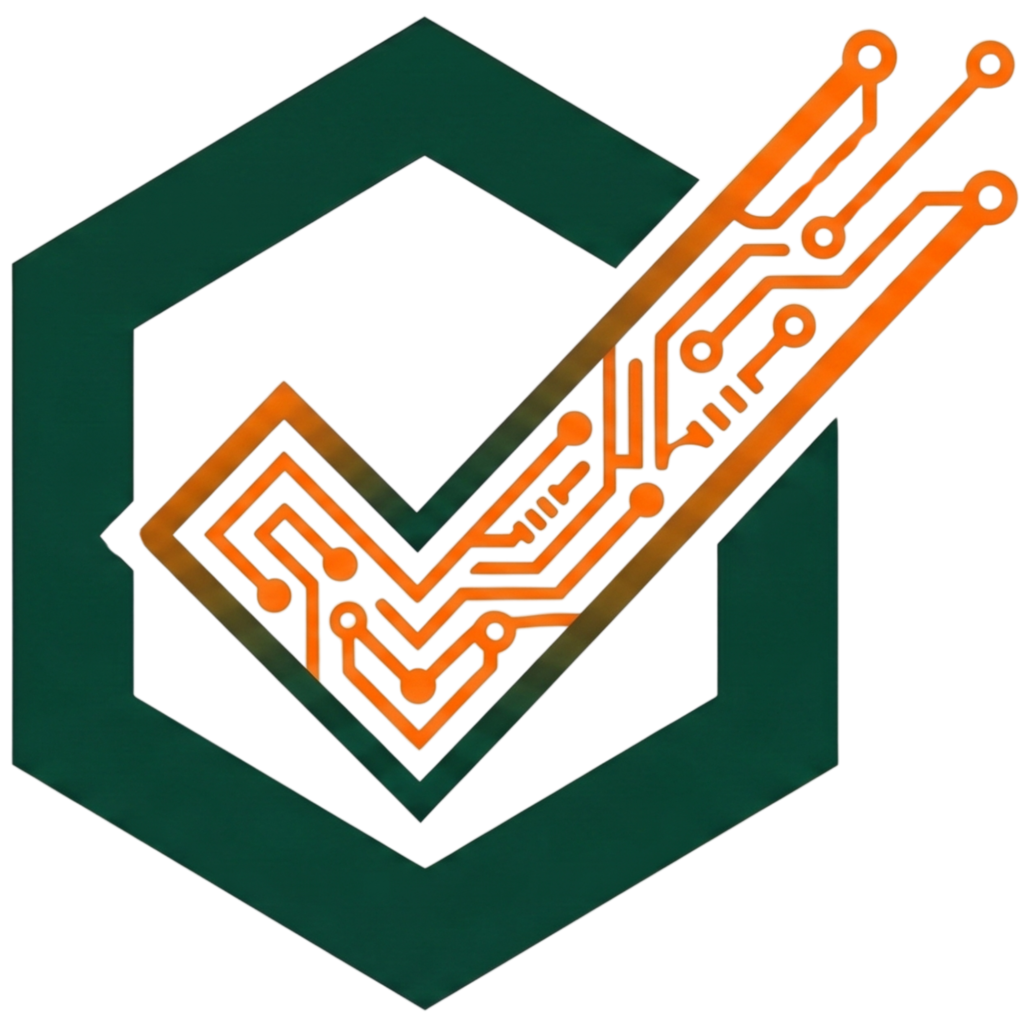

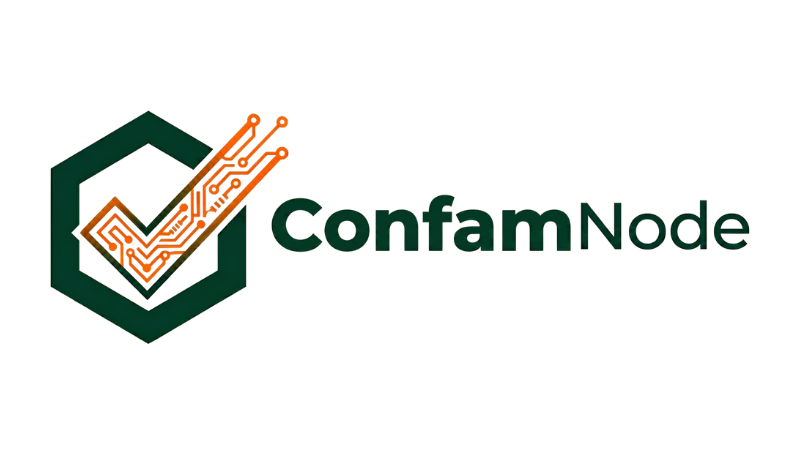

In [15]:
import os
import zipfile
from IPython.display import display, Image

dzf = zipfile.ZipFile(docx_path)
dlist = dzf.namelist()
# print(dlist)

for dname in dlist:
    _, ext = os.path.splitext(dname)
    if ext in [".png", ".gif", ".jpeg", ".jpg"]:
        with dzf.open(dname) as doc_img:
            im_data = doc_img.read() # read image
            display(Image(data=im_data))

## 9. Parse PDF — First Look

Our final source is:

`data/employee_travel_policy.pdf`

PDF is more difficult because its representation is primarily concerned with page rendering and layout.

For this notebook, we will perform a basic text extraction.

Detailed PDF layout analysis comes in **03 — PDF Parsing**.


In [16]:
import pymupdf

pdf_path = DATA_DIR / "employee_travel_policy.pdf"
with pymupdf.open(pdf_path) as pdf:
    print("Number of pages:", len(pdf))
    
    for page_number, page in enumerate(pdf):
        print(f"\n--- Page {page_number + 1} ---")
        print(page.get_text("text"))

Number of pages: 1

--- Page 1 ---
Employee Travel and Reimbursement Policy
Document ID: HR-TRV-2026-003 | Version: 4.0 | Effective: 1 July 2026
1. Purpose
This policy establishes the requirements for business travel, eligible expenses, receipts, approvals,
and reimbursement. It applies to employees travelling on approved company business.
2. Travel Approval
Employees must obtain manager approval before booking travel. International travel also requires
approval from the relevant department head.
3. Accommodation Limits
Location
Nightly limit
Notes
Lagos
₦120,000
Standard business accommodation
Abuja
₦110,000
Standard business accommodation
Port Harcourt
₦100,000
Standard business accommodation
International
Actual reasonable cost
Department approval required
4. Transportation
Employees should use reasonable and cost-effective transportation. Air travel should normally be
booked in economy class unless an approved exception applies.
5. Receipts and Reimbursement
Expense claims should b

The basic extraction gives us useful text.

However, the PDF also contains a table. A basic text representation may not preserve every visual relationship.

We therefore need to ask:

- Is the reading order correct?
- Where did each piece of text appear?
- Which content belongs to a table?
- Are there images?
- Is the PDF scanned?
- Can we preserve page-level provenance?

These questions are the focus of the next PDF parsing notebook.


## 10. Build a Common Parsed Document Representation

We have now parsed several different formats.

Although the source formats differ, we want downstream RAG stages to work with a consistent conceptual representation.

A simple representation might look like:

```python
parsed_document = {
    "document_id": "...",
    "source": "...",
    "document_type": "...",
    "metadata": {...},
    "content": [...],
    "provenance": {...},
}
```

Let's build one for the HTML document we just parsed.


In [17]:
parsed_html_document = {
    "document_id": article_metadata["document_id"],
    "source": html_path.name,
    "document_type": html_path.suffix.lstrip("."),
    "metadata": {
        "category": article_metadata["category"],
        "updated": article_metadata["updated"],
    },
    "content": sections,
    "provenance": {
        "source_path": str(html_path),
    },
}
parsed_html_document

{'document_id': 'KB-REF-2026-07',
 'source': 'support_refunds.html',
 'document_type': 'html',
 'metadata': {'category': 'Billing', 'updated': 'Updated 18 August 2026'},
 'content': [{'section_id': 'eligibility',
   'heading': 'Refund eligibility',
   'text': 'Refund eligibility Eligible customers can request a refund within 30 calendar days of the original purchase.'},
  {'section_id': 'processing',
   'heading': 'Processing time',
   'text': 'Processing time Approved refunds are normally processed within 7 business days .'},
  {'section_id': 'contact',
   'heading': 'Contact support',
   'text': 'Contact support Include your order reference when contacting the support team.'}],
 'provenance': {'source_path': 'data/support_refunds.html'}}

This is an important abstraction boundary.

The original source was HTML, but the next RAG stage does not need to know how HTML works.

It receives a parsed representation.

Conceptually:

```text
TXT ───────┐
Markdown ──┤
HTML ──────┤
DOCX ──────┼──→ Parsed Document Representation
PDF ───────┤
OCR ────────┘
```

Later, chunking can operate on this representation.


## 11. A Simple Parser Dispatch Function

As the number of supported formats grows, we don't want the rest of our application to contain format-specific logic everywhere.

A simple dispatch function can choose a parser based on the file type.

In [18]:
def parse_txt(path):
    return {
        "source": path.name,
        "document_type": "txt",
        "text": path.read_text(encoding="utf-8"),
    }


def parse_markdown(path):
    return {
        "source": path.name,
        "document_type": "md",
        "text": path.read_text(encoding="utf-8"),
    }


def parse_html(path):
    soup = BeautifulSoup(
        path.read_text(encoding="utf-8"),
        "html.parser",
    )

    return {
        "source": path.name,
        "document_type": "html",
        "text": soup.get_text(" ", strip=True),
    }


def parse_docx(path):
    document = Document(path)

    paragraphs = [
        paragraph.text
        for paragraph in document.paragraphs
        if paragraph.text.strip()
    ]

    return {
        "source": path.name,
        "document_type": "docx",
        "paragraphs": paragraphs,
    }


def parse_pdf(path):
    with pymupdf.open(pdf_path) as document:

        pages = [
            page.get_text("text")
            for page in document
        ]

    return {
        "source": path.name,
        "document_type": "pdf",
        "pages": pages,
    }


PARSERS = {
    ".txt": parse_txt,
    ".md": parse_markdown,
    ".html": parse_html,
    ".docx": parse_docx,
    ".pdf": parse_pdf,
}


def parse_document(path):
    parser = PARSERS.get(path.suffix.lower())

    if parser is None:
        raise ValueError(f"Unsupported document type: {path.suffix}")

    return parser(path)

Now we can run the same entry point against every supplied document.

In [19]:
parsed_documents = []

for filename in expected_files:
    path = DATA_DIR / filename
    parsed = parse_document(path)
    parsed_documents.append(parsed)

    print(
        f"{filename:45} -> "
        f"{parsed['document_type']}"
    )

customer_refund_policy.txt                    -> txt
internal_rag_engineering_guide.md             -> md
support_refunds.html                          -> html
q3_customer_support_operating_brief.docx      -> docx
employee_travel_policy.pdf                    -> pdf


This is intentionally a **small abstraction**, not a production parser framework.

The point is to see the architectural idea:

```text
                 parse_document()
                       │
          ┌────────────┼────────────┐
          ↓            ↓            ↓
        TXT          DOCX         PDF
       parser        parser       parser
          │            │            │
          └────────────┼────────────┘
                       ↓
             Parsed representation
```

Later, a production ingestion service can replace these simple functions with more sophisticated parsers such as Unstructured or Docling.


## 12. Parsing Errors Become RAG Errors

Consider the refund policy.

The source says customers may request a refund within **30 calendar days** of the original purchase date.

If parsing accidentally removes that information:

```text
Parser error
     ↓
Incomplete document
     ↓
Incomplete chunk
     ↓
Incomplete embedding
     ↓
Poor retrieval
     ↓
Incomplete context
     ↓
Wrong answer
```

The vector database cannot retrieve information that was never correctly ingested.

This is why:

> **Document parsing is part of the retrieval system.**


## 13. Exercise — Inspect Information Loss

Before moving on, inspect the five source documents and answer:

1. What useful structure exists in the Markdown document?
2. What information does the HTML parser preserve or discard?
3. Why should the DOCX table not automatically become plain text?
4. What information might a basic PDF text extractor fail to preserve?
5. Which metadata would you keep if these documents were going into a production RAG system?

There is no single universal answer.

The engineering decision depends on what the application needs to retrieve and cite.


## 14. When Should We Use a More Powerful Parser?

Start with the simplest tool that can reliably recover the information required by the application.

Conceptually:

```text
Can a simple parser recover the required information?
                 │
          ┌──────┴──────┐
         YES            NO
          │              │
       Use it       Specialized parser
                         │
                    OCR if needed
                         │
                  Still difficult?
                         │
                         ↓
                       VLM
```

General-purpose frameworks such as **Unstructured** and **Docling** become useful when we want a broader set of document formats and reusable document-element abstractions.

Vision-language models become relevant when conventional extraction is not sufficient, especially for difficult layouts.

These are advanced ingestion topics and will be covered later in the module.


## 15. What We Have Not Done

This notebook has deliberately not gone deeply into:

- PDF layout reconstruction
- OCR implementation
- Advanced table extraction
- Document cleaning and normalization
- Full metadata schema design
- Chunking
- Embeddings
- Vector database indexing
- General-purpose ingestion frameworks in depth
- VLM-based document understanding in depth

Those topics belong to later notebooks in the Document Ingestion sequence.


## Key Takeaways

1. Document parsing transforms source files into usable representations for RAG.
2. Different formats require different parsing strategies.
3. Parsing and chunking are separate stages.
4. Useful structure should be preserved when it carries meaning.
5. Tables should not automatically be flattened into ordinary text.
6. Metadata and provenance should remain connected to extracted content.
7. PDF parsing is sufficiently complex to deserve a dedicated workflow.
8. A parser can execute successfully while still producing incomplete or incorrect content.
9. Parsing errors propagate into chunking, retrieval, context construction, and generation.
10. A common parsed representation lets downstream RAG stages remain independent of source format.
11. Use the simplest parser that reliably preserves the information your application needs.


## What's Next?

We've now parsed TXT, Markdown, HTML, DOCX, and PDF documents.

Next we go deeper into:

## PDF Parsing

We will examine:

- PDF text extraction
- Pages and blocks
- Coordinates
- Reading order
- Tables
- Images
- Layout problems
- Scanned PDFs

That is where the document parsing problem becomes much more interesting.
